In [61]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [62]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [63]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-3.871522,1.660105,0.081960,3.423027,1.656585,0
1,-1.135875,2.245094,-1.657535,0.593164,2.425839,0
2,-1.385484,-0.794798,2.062787,-0.357569,-3.893789,1
3,2.114158,-0.450709,0.378920,1.212743,-0.308978,1
4,0.735996,-1.744212,1.731685,0.985843,-1.335507,1


In [64]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [65]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [66]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [67]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\BADAG\AppData\Local\Temp\ipykernel_17852\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [68]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\BADAG\AppData\Local\Temp\ipykernel_17852\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [69]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\BADAG\AppData\Local\Temp\ipykernel_17852\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [70]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col3', 'target'], dtype='object')
Index(['col5', 'col4', 'target'], dtype='object')
Index(['col5', 'col1', 'target'], dtype='object')


In [71]:
df3

,col5,col1,target
1,2.425839,-1.135875,0
42,-1.414021,-1.085160,1
3,-0.308978,2.114158,1
84,-1.987727,0.985093,1
30,0.252463,0.684714,1
52,-1.160224,-2.092171,1
4,-1.335507,0.735996,1
24,1.184626,-0.329048,0
82,0.799895,-0.037498,0
32,-1.799369,0.348122,0


In [72]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [73]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
from sklearn.tree import plot_tree

[Text(0.34615384615384615, 0.9444444444444444, 'x[1] <= -1.415\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2692307692307692, 0.8333333333333334, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.3076923076923077, 0.8888888888888888, 'True  '),
 Text(0.4230769230769231, 0.8333333333333334, 'x[1] <= 2.448\ngini = 0.487\nsamples = 43\nvalue = [18, 25]'),
 Text(0.3846153846153846, 0.8888888888888888, '  False'),
 Text(0.34615384615384615, 0.7222222222222222, 'x[0] <= 1.305\ngini = 0.45\nsamples = 38\nvalue = [13, 25]'),
 Text(0.15384615384615385, 0.6111111111111112, 'x[0] <= -1.594\ngini = 0.245\nsamples = 21\nvalue = [3, 18]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.23076923076923078, 0.5, 'x[1] <= 0.31\ngini = 0.18\nsamples = 20\nvalue = [2, 18]'),
 Text(0.15384615384615385, 0.3888888888888889, 'x[1] <= -0.107\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.07692307692307693, 0.2777777777777778, 'gini = 0.0\nsamples = 4\nval

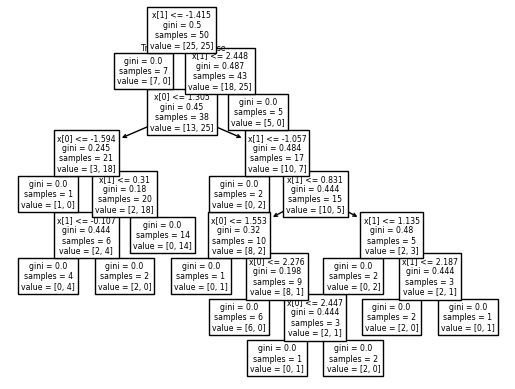

In [75]:
plot_tree(clf1)

[Text(0.6666666666666666, 0.9375, 'x[0] <= 0.777\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.5, 0.8125, 'x[0] <= -0.678\ngini = 0.339\nsamples = 37\nvalue = [8, 29]'),
 Text(0.5833333333333333, 0.875, 'True  '),
 Text(0.3333333333333333, 0.6875, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.6666666666666666, 0.6875, 'x[1] <= 1.328\ngini = 0.463\nsamples = 22\nvalue = [8, 14]'),
 Text(0.5, 0.5625, 'x[0] <= 0.127\ngini = 0.291\nsamples = 17\nvalue = [3, 14]'),
 Text(0.3333333333333333, 0.4375, 'x[0] <= -0.28\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.16666666666666666, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.3125, 'x[0] <= -0.136\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3333333333333333, 0.1875, 'x[0] <= -0.221\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.16666666666666666, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.666666666666666

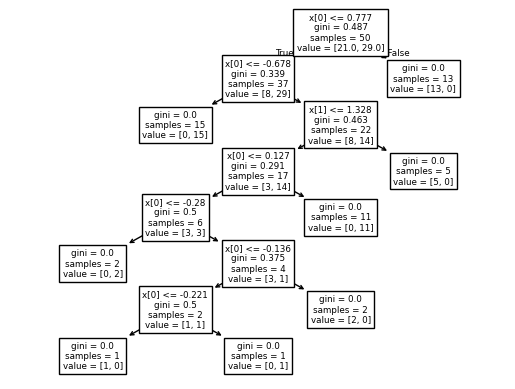

In [76]:
plot_tree(clf2)

[Text(0.4166666666666667, 0.9285714285714286, 'x[0] <= -0.678\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[1] <= -2.177\ngini = 0.188\nsamples = 19\nvalue = [2, 17]'),
 Text(0.2916666666666667, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.6428571428571429, 'x[0] <= -1.799\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.16666666666666666, 0.5, 'x[0] <= -1.894\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.08333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.25, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.6666666666666666, 0.7857142857142857, 'x[0] <= 0.786\ngini = 0.271\nsamples = 31\nvalue = [26, 5]'),
 Text(0.5416666666666666, 0.8571428571428572, '  False'),
 Text(0.5833333333333334

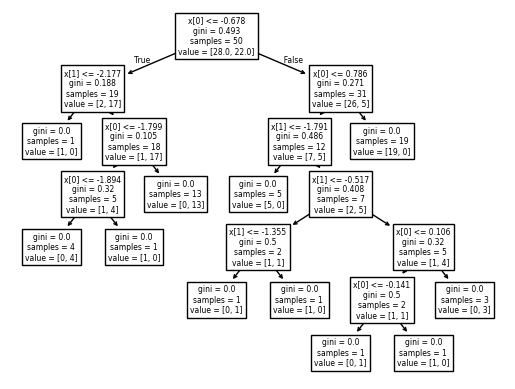

In [77]:
plot_tree(clf3)

In [83]:
clf1.predict(np.array([-0.308978,	2.114158	]).reshape(1,2))

C:\Users\BADAG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [84]:
clf2.predict(np.array([-0.308978,	2.114158	]).reshape(1,2))

C:\Users\BADAG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [85]:
clf3.predict(np.array([-0.308978,	2.114158	]).reshape(1,2))

C:\Users\BADAG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [81]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
23,3.401960,0.992934,1.575828,2.690716,-2.275072,1
22,0.529660,-2.065377,-0.720434,0.649027,0.513099,1
24,-0.329048,-0.397793,-0.101624,0.611050,1.184626,0
24,-0.329048,-0.397793,-0.101624,0.611050,1.184626,0
87,-1.769440,-3.163651,1.285131,-0.545945,0.771663,1
14,-1.972805,2.892949,-0.780162,1.982978,3.118831,0
83,-0.340381,-0.445391,-0.810851,-0.252034,-1.104358,1
60,1.384966,-1.415541,2.265723,0.636066,0.735166,1
4,0.735996,-1.744212,1.731685,0.985843,-1.335507,1
27,4.010417,0.085993,0.199128,2.368373,-0.794580,1


In [82]:
df


,col1,col2,col3,col4,col5,target
0,-3.871522,1.660105,0.081960,3.423027,1.656585,0
1,-1.135875,2.245094,-1.657535,0.593164,2.425839,0
2,-1.385484,-0.794798,2.062787,-0.357569,-3.893789,1
3,2.114158,-0.450709,0.378920,1.212743,-0.308978,1
4,0.735996,-1.744212,1.731685,0.985843,-1.335507,1
...,...,...,...,...,...,...
95,-0.093682,-2.665970,1.814952,0.006788,0.505485,1
96,1.206628,-1.230542,1.689580,0.892108,-1.798892,1
97,-0.782118,1.030618,2.171979,1.051627,0.070254,0
98,0.621864,-0.240760,0.241320,1.017560,2.050937,0
